# A7 IndoBERT training (GPU)
Runs package logic on hash-verified train/validation only. It must not read the locked test split. Follow `docs/indobert-training-runbook.md` before execution.

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [4]:
from pathlib import Path

split_drive = Path("/content/drive/MyDrive/SIPATURE/inputs/splits")

print("Folder ditemukan:", split_drive.exists())
print("Isi folder:")
for file in sorted(split_drive.iterdir()):
    print("-", file.name)

Folder ditemukan: True
Isi folder:
- split_manifest_silver_v1.json
- train_silver_v1.jsonl
- validation_silver_v1.jsonl


In [9]:
from google.colab import userdata
import base64
import os
import shutil
import subprocess

token = userdata.get("GITHUB_TOKEN")
assert token, "GITHUB_TOKEN tidak ditemukan di Colab Secrets"

# GitHub menerima format Basic: x-access-token:<token>
credentials = f"x-access-token:{token}"
authorization = base64.b64encode(credentials.encode()).decode()

repo_dir = "/content/hackathon"
shutil.rmtree(repo_dir, ignore_errors=True)

environment = os.environ.copy()
environment["GIT_CONFIG_COUNT"] = "1"
environment["GIT_CONFIG_KEY_0"] = "http.extraHeader"
environment["GIT_CONFIG_VALUE_0"] = f"Authorization: Basic {authorization}"

result = subprocess.run(
    [
        "git",
        "clone",
        "https://github.com/jodypangaribuan/hackathon.git",
        repo_dir,
    ],
    env=environment,
    text=True,
    capture_output=True,
)

print("Return code:", result.returncode)
print(result.stdout)
print(result.stderr)

assert result.returncode == 0, "Clone gagal. Periksa izin token GitHub."

Return code: 0

Cloning into '/content/hackathon'...



In [10]:
%cd /content/hackathon/ml
!git log --oneline -3

/content/hackathon/ml
24f140c (HEAD -> main, origin/main, origin/HEAD) feat: implement IndoBERT pipeline for aspect-based polarity and severity training
28d3844 refactor: update dataset EDA visualization labels, refine project report documentation, and refresh manifest metadata.
21e51bd feat: implement keyword and TF-IDF baselines for silver reference evaluation


In [11]:
%cd /content/hackathon/ml
!python -m pip install -r requirements-colab.lock.txt
!python -m pip install --no-deps -e .

/content/hackathon/ml
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 62.0/62.0 kB 6.0 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 91.2/91.2 kB 9.3 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 62.0/62.0 kB 6.5 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 40.9/40.9 kB 3.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 16.5/16.5 MB 104.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.4/12.4 MB 109.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 42.1/42.1 MB 21.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.5/9.5 MB 134.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 37.3/37.3 MB 18.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.1/3.1 MB 110.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.6/8.6 MB 131.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 821.0/821.0 MB 2.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━

In [12]:
import torch
import transformers
import datasets
import accelerate

print("PyTorch:", torch.__version__)
print("Transformers:", transformers.__version__)
print("Datasets:", datasets.__version__)
print("Accelerate:", accelerate.__version__)
print("CUDA tersedia:", torch.cuda.is_available())

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

PyTorch: 2.7.1+cu126
Transformers: 4.53.2
Datasets: 3.6.0
Accelerate: 1.8.1
CUDA tersedia: True
GPU: Tesla T4


In [13]:
from pathlib import Path
import shutil

drive_splits = Path("/content/drive/MyDrive/SIPATURE/inputs/splits")
local_splits = Path("/content/hackathon/ml/data/splits")

local_splits.mkdir(parents=True, exist_ok=True)

files_to_copy = [
    "train_silver_v1.jsonl",
    "validation_silver_v1.jsonl",
    "split_manifest_silver_v1.json",
]

for filename in files_to_copy:
    source = drive_splits / filename
    destination = local_splits / filename

    assert source.is_file(), f"File tidak ditemukan: {source}"

    shutil.copy2(source, destination)
    print(f"Berhasil disalin: {filename} ({destination.stat().st_size:,} byte)")

print("\nIsi folder split lokal:")

for file in sorted(local_splits.iterdir()):
    print("-", file.name)

Berhasil disalin: train_silver_v1.jsonl (798,544 byte)
Berhasil disalin: validation_silver_v1.jsonl (166,813 byte)
Berhasil disalin: split_manifest_silver_v1.json (14,405 byte)

Isi folder split lokal:
- README.md
- split_manifest_silver_v1.json
- train_silver_v1.jsonl
- validation_silver_v1.jsonl


In [15]:
%cd /content/hackathon/ml
%pip install --no-deps -e .

/content/hackathon/ml
Obtaining file:///content/hackathon/ml
  Installing build dependencies ... done
  Checking if build backend supports build_editable ... done
  Getting requirements to build editable ... done
  Preparing editable metadata (pyproject.toml) ... done
  Building editable for sipature-ml (pyproject.toml) ... done
  Created wheel for sipature-ml: filename=sipature_ml-0.1.0-0.editable-py3-none-any.whl size=3177 sha256=5c8930ff8f6e3500ead3acdddb5581197972e5aeafc01bc5156966014ca1ff75
  Stored in directory: /tmp/pip-ephem-wheel-cache-1kwb0u5n/wheels/38/ed/47/7d6d64ef9cfba4b46e7b5732ea81e4a46aee1d5accb9c7cd88
Successfully built sipature-ml
  Attempting uninstall: sipature-ml
    Found existing installation: sipature-ml 0.1.0
    Uninstalling sipature-ml-0.1.0:
      Successfully uninstalled sipature-ml-0.1.0


In [17]:
import sys
from pathlib import Path

source_dir = Path("/content/hackathon/ml/src")

assert source_dir.is_dir(), f"Folder tidak ditemukan: {source_dir}"

if str(source_dir) not in sys.path:
    sys.path.insert(0, str(source_dir))

import sipature_ml

print("Modul SIPATURE berhasil dimuat dari:")
print(sipature_ml.__file__)

Modul SIPATURE berhasil dimuat dari:
/content/hackathon/ml/src/sipature_ml/__init__.py


In [1]:
import numpy
import torch

print("NumPy:", numpy.__version__)
print("PyTorch:", torch.__version__)
print("CUDA tersedia:", torch.cuda.is_available())

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

NumPy: 2.2.6
PyTorch: 2.7.1+cu126
CUDA tersedia: True
GPU: Tesla T4


In [3]:
import sys
from pathlib import Path

project_dir = Path("/content/hackathon/ml")
source_dir = project_dir / "src"

print("Repository ditemukan:", project_dir.is_dir())
print("Folder source ditemukan:", source_dir.is_dir())

assert project_dir.is_dir(), "Repository hilang setelah restart. Jangan lanjutkan."
assert source_dir.is_dir(), "Folder source SIPATURE tidak ditemukan."

if str(source_dir) not in sys.path:
    sys.path.insert(0, str(source_dir))

import sipature_ml

print("Modul SIPATURE berhasil dimuat dari:")
print(sipature_ml.__file__)

Repository ditemukan: True
Folder source ditemukan: True
Modul SIPATURE berhasil dimuat dari:
/content/hackathon/ml/src/sipature_ml/__init__.py


In [4]:
import json
from pathlib import Path

from sipature_ml.indobert import verify_training_split_hashes

split_dir = Path("/content/hackathon/ml/data/splits")
manifest_path = split_dir / "split_manifest_silver_v1.json"

assert manifest_path.is_file(), f"Manifest tidak ditemukan: {manifest_path}"

manifest = json.loads(
    manifest_path.read_text(encoding="utf-8")
)

verified_hashes = verify_training_split_hashes(
    split_dir=split_dir,
    manifest=manifest,
)

print("Validasi hash berhasil:")
for split, file_hash in verified_hashes.items():
    print(f"- {split}: {file_hash}")

print("\nLocked test pada manifest:", manifest["test_is_locked"])
print("Split valid:", manifest["validation"]["valid"])

Validasi hash berhasil:
- train: 31c31803be592a3c91576f42abbc3fcf562d2f82c126b2856848e88639ab3fc4
- validation: 7c2f5f911ea33c6854ad1adc21e41a58befb6b24b31cb5ef2b8e03b7b771477c

Locked test pada manifest: True
Split valid: True


In [5]:
from sipature_ml.config import load_config
from sipature_ml.indobert import validate_indobert_config

training_config = load_config("training")
indobert_config = validate_indobert_config(training_config)

print("Model ID:", indobert_config["model_id"])
print("Revision:", indobert_config["revision"])
print("Lisensi:", indobert_config["license"])
print("Jumlah parameter:", f'{indobert_config["parameter_count"]:,}')
print("Tokenizer:", indobert_config["tokenizer"])
print("Max length:", indobert_config["max_length"])
print("Batch size:", indobert_config["batch_size"])
print(
    "Effective batch size:",
    indobert_config["batch_size"]
    * indobert_config["gradient_accumulation_steps"],
)
print("Epoch:", indobert_config["epochs"])
print("Learning rate:", indobert_config["learning_rate"])
print("Aspect loss:", indobert_config["aspect_loss"])
print("Classification loss:", indobert_config["classification_loss"])
print("Mixed precision:", indobert_config["mixed_precision"])

Model ID: indobenchmark/indobert-base-p1
Revision: c2cd0b51ddce6580eb35263b39b0a1e5fb0a39e2
Lisensi: MIT
Jumlah parameter: 124,500,000
Tokenizer: BertTokenizer (WordPiece)
Max length: 192
Batch size: 16
Effective batch size: 32
Epoch: 4
Learning rate: 2e-05
Aspect loss: weighted_bce
Classification loss: weighted_cross_entropy
Mixed precision: fp16


In [6]:
from transformers import BertTokenizer

MODEL_ID = indobert_config["model_id"]
MODEL_REVISION = indobert_config["revision"]

print("Mengunduh tokenizer...")

tokenizer = BertTokenizer.from_pretrained(
    MODEL_ID,
    revision=MODEL_REVISION,
)

print("Tokenizer berhasil dimuat.")
print("Class:", tokenizer.__class__.__name__)
print("Ukuran vocabulary:", tokenizer.vocab_size)
print("Model max length:", tokenizer.model_max_length)

Mengunduh tokenizer...


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


tokenizer_config.json:   0%|          | 0.00/2.00 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json: 0.00B [00:00, ?B/s]

Tokenizer berhasil dimuat.
Class: BertTokenizer
Ukuran vocabulary: 30521
Model max length: 1000000000000000019884624838656


In [8]:
sample_text = "Pemandangannya indah, tetapi jalan menuju lokasi rusak."

encoded = tokenizer(
    sample_text,
    add_special_tokens=True,
    truncation=False,
)

tokens = tokenizer.convert_ids_to_tokens(encoded["input_ids"])

print("Teks:", sample_text)
print("Token:", tokens)
print("Token IDs:", encoded["input_ids"])
print("Jumlah token:", len(encoded["input_ids"]))
print("ID token terbesar pada contoh:", max(encoded["input_ids"]))
print("Ukuran vocabulary tokenizer:", tokenizer.vocab_size)
print("Kapasitas embedding model:", model_config.vocab_size)

assert max(encoded["input_ids"]) < model_config.vocab_size

print("\nToken ID berada dalam kapasitas embedding model: AMAN")

Teks: Pemandangannya indah, tetapi jalan menuju lokasi rusak.
Token: ['[CLS]', 'pemandangan', '##nya', 'indah', ',', 'tetapi', 'jalan', 'menuju', 'lokasi', 'rusak', '.', '[SEP]']
Token IDs: [2, 4962, 57, 1972, 30468, 638, 795, 1894, 1604, 3655, 30470, 3]
Jumlah token: 12
ID token terbesar pada contoh: 30470
Ukuran vocabulary tokenizer: 30521
Kapasitas embedding model: 50000

Token ID berada dalam kapasitas embedding model: AMAN


In [9]:
import json
from pathlib import Path

from sipature_ml.indobert import token_length_summary

split_dir = Path("/content/hackathon/ml/data/splits")
max_length = indobert_config["max_length"]


def read_jsonl(path):
    return [
        json.loads(line)
        for line in path.read_text(encoding="utf-8").splitlines()
        if line.strip()
    ]


records_by_split = {
    "train": read_jsonl(split_dir / "train_silver_v1.jsonl"),
    "validation": read_jsonl(split_dir / "validation_silver_v1.jsonl"),
}

coverage_report = {}

for split_name, records in records_by_split.items():
    encoded = tokenizer(
        [record["text"] for record in records],
        add_special_tokens=True,
        truncation=False,
        padding=False,
    )

    token_lengths = [
        len(input_ids)
        for input_ids in encoded["input_ids"]
    ]

    coverage_report[split_name] = token_length_summary(
        token_lengths,
        max_length=max_length,
    )

print(json.dumps(coverage_report, indent=2))

{
  "train": {
    "records": 922,
    "max_length": 192,
    "p50_tokens": 23,
    "p90_tokens": 97,
    "p95_tokens": 139,
    "p99_tokens": 304,
    "maximum_tokens": 544,
    "records_within_max_length": 896,
    "coverage_at_max_length": 0.9718004338394793
  },
  "validation": {
    "records": 196,
    "max_length": 192,
    "p50_tokens": 23,
    "p90_tokens": 74,
    "p95_tokens": 130,
    "p99_tokens": 319,
    "maximum_tokens": 525,
    "records_within_max_length": 192,
    "coverage_at_max_length": 0.9795918367346939
  }
}


In [10]:
from collections import Counter

from sipature_ml.config import load_config
from sipature_ml.indobert import (
    build_aspect_targets,
    build_polarity_instances,
    build_severity_instances,
    severity_support_gate,
)

taxonomy = load_config("taxonomy")
aspects = sorted(taxonomy["aspect_definitions"])

aspect_targets = {
    split: build_aspect_targets(records, aspects)
    for split, records in records_by_split.items()
}

polarity_instances = {
    split: build_polarity_instances(records)
    for split, records in records_by_split.items()
}

severity_instances = {
    split: build_severity_instances(records)
    for split, records in records_by_split.items()
}

polarity_names = ["positive", "negative", "neutral"]
severity_names = ["low", "medium", "high"]

print("Jumlah review untuk aspect detection:")
for split in ("train", "validation"):
    print(f"- {split}: {len(aspect_targets[split])}")

print("\nJumlah instance polarity:")
for split in ("train", "validation"):
    counts = Counter(
        polarity_names[item["label"]]
        for item in polarity_instances[split]
    )
    print(f"- {split}: {len(polarity_instances[split])}")
    print("  distribusi:", dict(counts))

print("\nJumlah instance severity:")
for split in ("train", "validation"):
    counts = Counter(
        severity_names[item["label"]]
        for item in severity_instances[split]
    )
    print(f"- {split}: {len(severity_instances[split])}")
    print("  distribusi:", dict(counts))

severity_gate = severity_support_gate(
    train_instances=severity_instances["train"],
    validation_instances=severity_instances["validation"],
    min_train_per_class=indobert_config["severity_min_train_per_class"],
    min_validation_per_class=indobert_config["severity_min_validation_per_class"],
)

print("\nKeputusan severity gate:")
print(json.dumps(severity_gate, indent=2))

Jumlah review untuk aspect detection:
- train: 922
- validation: 196

Jumlah instance polarity:
- train: 1244
  distribusi: {'negative': 422, 'positive': 521, 'neutral': 301}
- validation: 260
  distribusi: {'positive': 107, 'negative': 91, 'neutral': 62}

Jumlah instance severity:
- train: 422
  distribusi: {'medium': 195, 'low': 208, 'high': 19}
- validation: 91
  distribusi: {'low': 38, 'medium': 47, 'high': 6}

Keputusan severity gate:
{
  "supported": false,
  "train_support": {
    "low": 208,
    "medium": 195,
    "high": 19
  },
  "validation_support": {
    "low": 38,
    "medium": 47,
    "high": 6
  },
  "minimum_train_per_class": 20,
  "minimum_validation_per_class": 5,
  "unsupported_classes": [
    "high"
  ]
}


In [2]:
import sys
import subprocess

print("Python:", sys.executable)

subprocess.run(
    [sys.executable, "-m", "pip", "uninstall", "-y", "torchvision"],
    check=False,
)

check = subprocess.run(
    [sys.executable, "-m", "pip", "show", "torchvision"],
    text=True,
    capture_output=True,
)

print("\nPemeriksaan setelah uninstall:")
print("Return code:", check.returncode)
print(check.stdout or "torchvision tidak ditemukan: OK")

Python: /usr/bin/python3

Pemeriksaan setelah uninstall:
Return code: 1
torchvision tidak ditemukan: OK


In [1]:
import importlib.util
import torch
import transformers

print("PyTorch:", torch.__version__)
print("Transformers:", transformers.__version__)
print("CUDA tersedia:", torch.cuda.is_available())
print("GPU:", torch.cuda.get_device_name(0))
print("Torchvision ditemukan:", importlib.util.find_spec("torchvision") is not None)

from transformers import BertForSequenceClassification

print("BertForSequenceClassification berhasil diimpor: OK")

PyTorch: 2.7.1+cu126
Transformers: 4.53.2
CUDA tersedia: True
GPU: Tesla T4
Torchvision ditemukan: False
BertForSequenceClassification berhasil diimpor: OK


In [3]:
from google.colab import drive

drive.mount("/content/drive")

import shutil
import sys
from pathlib import Path

project_dir = Path("/content/hackathon/ml")
source_dir = project_dir / "src"
split_dir = project_dir / "data" / "splits"

assert project_dir.is_dir(), "Repository tidak ditemukan."
assert source_dir.is_dir(), "Source SIPATURE tidak ditemukan."

if str(source_dir) not in sys.path:
    sys.path.insert(0, str(source_dir))

import sipature_ml

required_files = [
    split_dir / "train_silver_v1.jsonl",
    split_dir / "validation_silver_v1.jsonl",
    split_dir / "split_manifest_silver_v1.json",
]

print("Modul SIPATURE:", sipature_ml.__file__)

for file in required_files:
    print(f"{file.name}: {file.is_file()}")
    assert file.is_file(), f"File tidak ditemukan: {file}"

failed_run = Path(
    "/content/drive/MyDrive/SIPATURE/runs/"
    "20260801-1017_indobert-silver-v1"
)

if failed_run.exists():
    shutil.rmtree(failed_run)
    print("Folder run gagal berhasil dihapus.")
else:
    print("Folder run gagal tidak ditemukan, tidak perlu dihapus.")

print("Lingkungan siap:", not failed_run.exists())

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Modul SIPATURE: /content/hackathon/ml/src/sipature_ml/__init__.py
train_silver_v1.jsonl: True
validation_silver_v1.jsonl: True
split_manifest_silver_v1.json: True
Folder run gagal berhasil dihapus.
Lingkungan siap: True


In [4]:
import torch
from transformers import BertForSequenceClassification

MODEL_ID = "indobenchmark/indobert-base-p1"
MODEL_REVISION = "c2cd0b51ddce6580eb35263b39b0a1e5fb0a39e2"

print("Mengunduh dan memuat bobot IndoBERT...")

test_model = BertForSequenceClassification.from_pretrained(
    MODEL_ID,
    revision=MODEL_REVISION,
    num_labels=14,
    problem_type="multi_label_classification",
)

test_model = test_model.to("cuda")

print("Model berhasil dimuat.")
print("Device:", next(test_model.parameters()).device)
print("Jumlah label:", test_model.config.num_labels)
print(
    "Jumlah parameter:",
    f"{sum(parameter.numel() for parameter in test_model.parameters()):,}",
)

Mengunduh dan memuat bobot IndoBERT...


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


pytorch_model.bin:   0%|          | 0.00/498M [00:00<?, ?B/s]

Some weights of BertForSequenceClassification were not initialized from the model checkpoint at indobenchmark/indobert-base-p1 and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Model berhasil dimuat.
Device: cuda:0
Jumlah label: 14
Jumlah parameter: 124,452,110


In [5]:
del test_model
torch.cuda.empty_cache()

print(
    "GPU memory allocated setelah cleanup:",
    round(torch.cuda.memory_allocated() / 1024**2, 2),
    "MB",
)

GPU memory allocated setelah cleanup: 0.0 MB


In [6]:
import json
import torch

from datetime import datetime, timezone
from pathlib import Path

from sipature_ml.indobert import run_indobert_training

RUN_ID = datetime.now(timezone.utc).strftime(
    "%Y%m%d-%H%M_indobert-silver-v1"
)

split_dir = Path("/content/hackathon/ml/data/splits")
artifact_dir = Path("/content/drive/MyDrive/SIPATURE")
run_dir = artifact_dir / "runs" / RUN_ID

print("Run ID:", RUN_ID)
print("Input:", split_dir)
print("Output:", run_dir)
print("GPU:", torch.cuda.get_device_name(0))
print("Training task: aspect dan polarity")
print("Severity: otomatis dilewati jika gate tidak terpenuhi")

assert torch.cuda.is_available(), "CUDA GPU tidak tersedia."
assert not run_dir.exists(), f"Run ID sudah tersedia: {run_dir}"

summary = run_indobert_training(
    split_dir=split_dir,
    artifact_dir=artifact_dir,
    run_id=RUN_ID,
)

print("\nTRAINING SELESAI")
print(json.dumps(summary, indent=2))

Run ID: 20260801-1024_indobert-silver-v1
Input: /content/hackathon/ml/data/splits
Output: /content/drive/MyDrive/SIPATURE/runs/20260801-1024_indobert-silver-v1
GPU: Tesla T4
Training task: aspect dan polarity
Severity: otomatis dilewati jika gate tidak terpenuhi


Some weights of BertForSequenceClassification were not initialized from the model checkpoint at indobenchmark/indobert-base-p1 and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Epoch,Training Loss,Validation Loss,Macro F1
1,1.210000,1.045982,0.282174
2,0.955800,0.911108,0.303958
3,0.803300,0.815246,0.379969
4,0.716800,0.782394,0.401225


Some weights of BertForSequenceClassification were not initialized from the model checkpoint at indobenchmark/indobert-base-p1 and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Epoch,Training Loss,Validation Loss,Macro F1
1,0.985600,0.776207,0.645347
2,0.710800,0.697463,0.677918
3,0.545900,0.691235,0.703925
4,0.439300,0.696197,0.704404


Asking to truncate to max_length but no maximum length is provided and the model has no predefined maximum length. Default to no truncation.
Asking to truncate to max_length but no maximum length is provided and the model has no predefined maximum length. Default to no truncation.



TRAINING SELESAI
{
  "run_id": "20260801-1024_indobert-silver-v1",
  "status": "trained_train_validation_only",
  "test_read": false,
  "reference_label_type": "ai_assisted_weak_supervision_silver",
  "split_version": "silver-split-1.0.0",
  "input_hashes": {
    "train": "31c31803be592a3c91576f42abbc3fcf562d2f82c126b2856848e88639ab3fc4",
    "validation": "7c2f5f911ea33c6854ad1adc21e41a58befb6b24b31cb5ef2b8e03b7b771477c"
  },
  "token_length_coverage": {
    "train": {
      "records": 922,
      "max_length": 192,
      "p50_tokens": 23,
      "p90_tokens": 97,
      "p95_tokens": 139,
      "p99_tokens": 304,
      "maximum_tokens": 544,
      "records_within_max_length": 896,
      "coverage_at_max_length": 0.9718004338394793
    },
    "validation": {
      "records": 196,
      "max_length": 192,
      "p50_tokens": 23,
      "p90_tokens": 74,
      "p95_tokens": 130,
      "p99_tokens": 319,
      "maximum_tokens": 525,
      "records_within_max_length": 192,
      "coverage_at

In [8]:
from pathlib import Path

RUN_ID = "20260801-1024_indobert-silver-v1"

run_dir = (
    Path("/content/drive/MyDrive/SIPATURE/runs")
    / RUN_ID
)

for task in ("aspect", "polarity"):
    model_dir = run_dir / task / "model"

    print(f"\nIsi folder {task}/model:")

    for path in sorted(model_dir.iterdir()):
        print(f"- {path.name}: {path.stat().st_size:,} byte")

    safetensors_path = model_dir / "model.safetensors"

    assert safetensors_path.is_file(), (
        f"Bobot model tidak ditemukan: {safetensors_path}"
    )

    print(
        f"Bobot {task} tersedia dalam format safetensors:",
        f"{safetensors_path.stat().st_size:,} byte",
    )


Isi folder aspect/model:
- config.json: 1,547 byte
- model.safetensors: 497,831,984 byte
- special_tokens_map.json: 125 byte
- tokenizer_config.json: 1,292 byte
- training_args.bin: 5,841 byte
- vocab.txt: 229,167 byte
Bobot aspect tersedia dalam format safetensors: 497,831,984 byte

Isi folder polarity/model:
- config.json: 1,044 byte
- model.safetensors: 497,798,148 byte
- special_tokens_map.json: 125 byte
- tokenizer_config.json: 1,292 byte
- training_args.bin: 5,905 byte
- vocab.txt: 229,167 byte
Bobot polarity tersedia dalam format safetensors: 497,798,148 byte


In [9]:
import hashlib
import json
from pathlib import Path

RUN_ID = "20260801-1024_indobert-silver-v1"

run_dir = (
    Path("/content/drive/MyDrive/SIPATURE/runs")
    / RUN_ID
)

manifest_path = run_dir / "manifest.json"


def sha256_file(path: Path) -> str:
    digest = hashlib.sha256()

    with path.open("rb") as file:
        for chunk in iter(lambda: file.read(1024 * 1024), b""):
            digest.update(chunk)

    return digest.hexdigest()


manifest = json.loads(
    manifest_path.read_text(encoding="utf-8")
)

artifact_hashes = manifest.get("artifact_hashes", {})

print("Jumlah artifact dalam manifest:", len(artifact_hashes))

hash_errors = []

for relative_path, expected_hash in artifact_hashes.items():
    artifact_path = run_dir / relative_path

    if not artifact_path.is_file():
        hash_errors.append(
            f"File tidak ditemukan: {relative_path}"
        )
        continue

    actual_hash = sha256_file(artifact_path)

    if actual_hash != expected_hash:
        hash_errors.append(
            f"Hash berbeda: {relative_path}"
        )

print("Jumlah masalah hash:", len(hash_errors))

if hash_errors:
    print("\nMasalah yang ditemukan:")

    for error in hash_errors:
        print("-", error)
else:
    print("Seluruh hash artifact valid.")

Jumlah artifact dalam manifest: 65
Jumlah masalah hash: 0
Seluruh hash artifact valid.


Kurva Aspect Detection


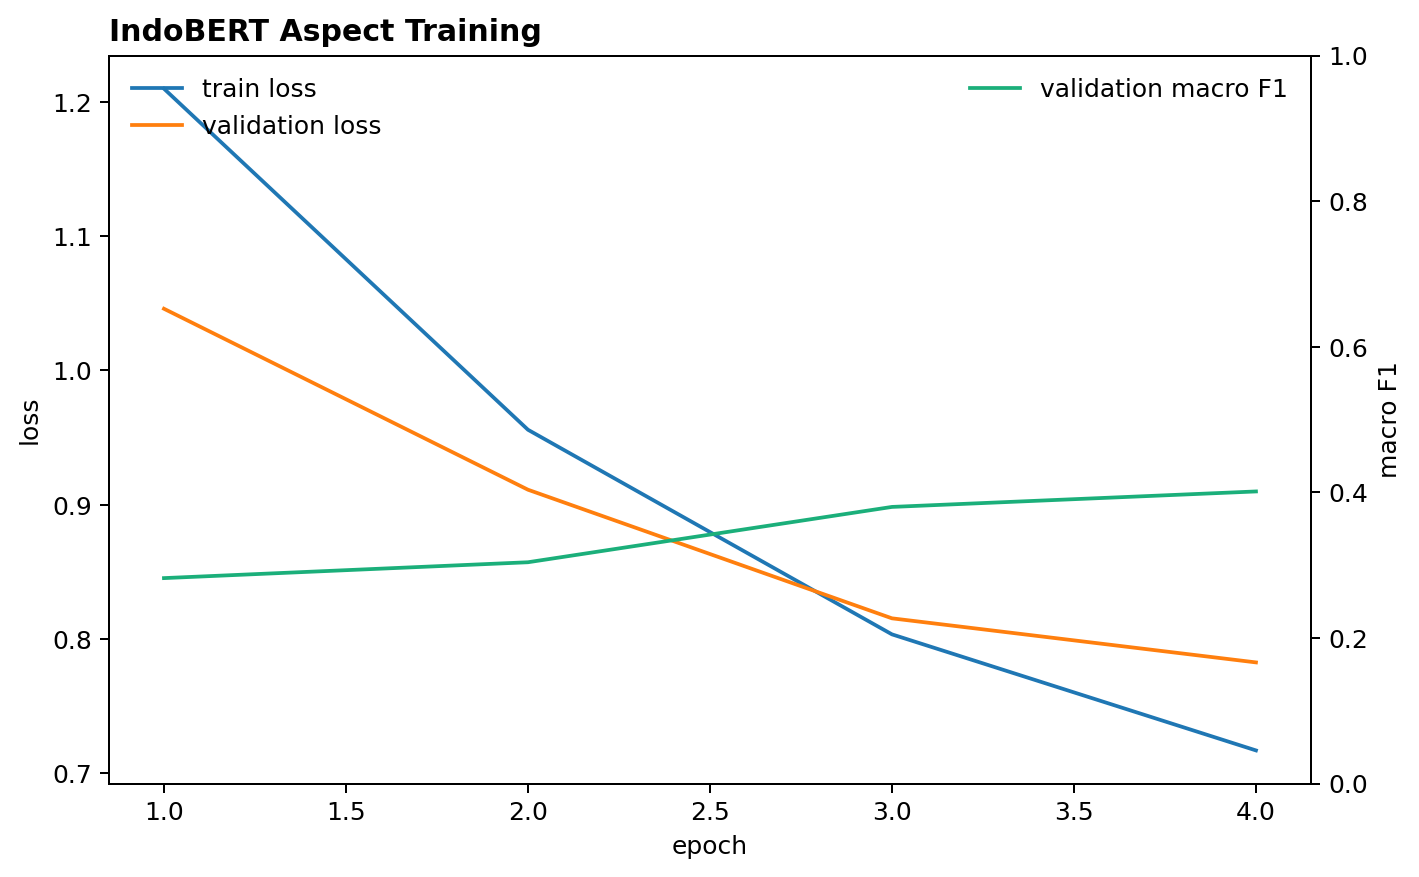

Kurva Polarity


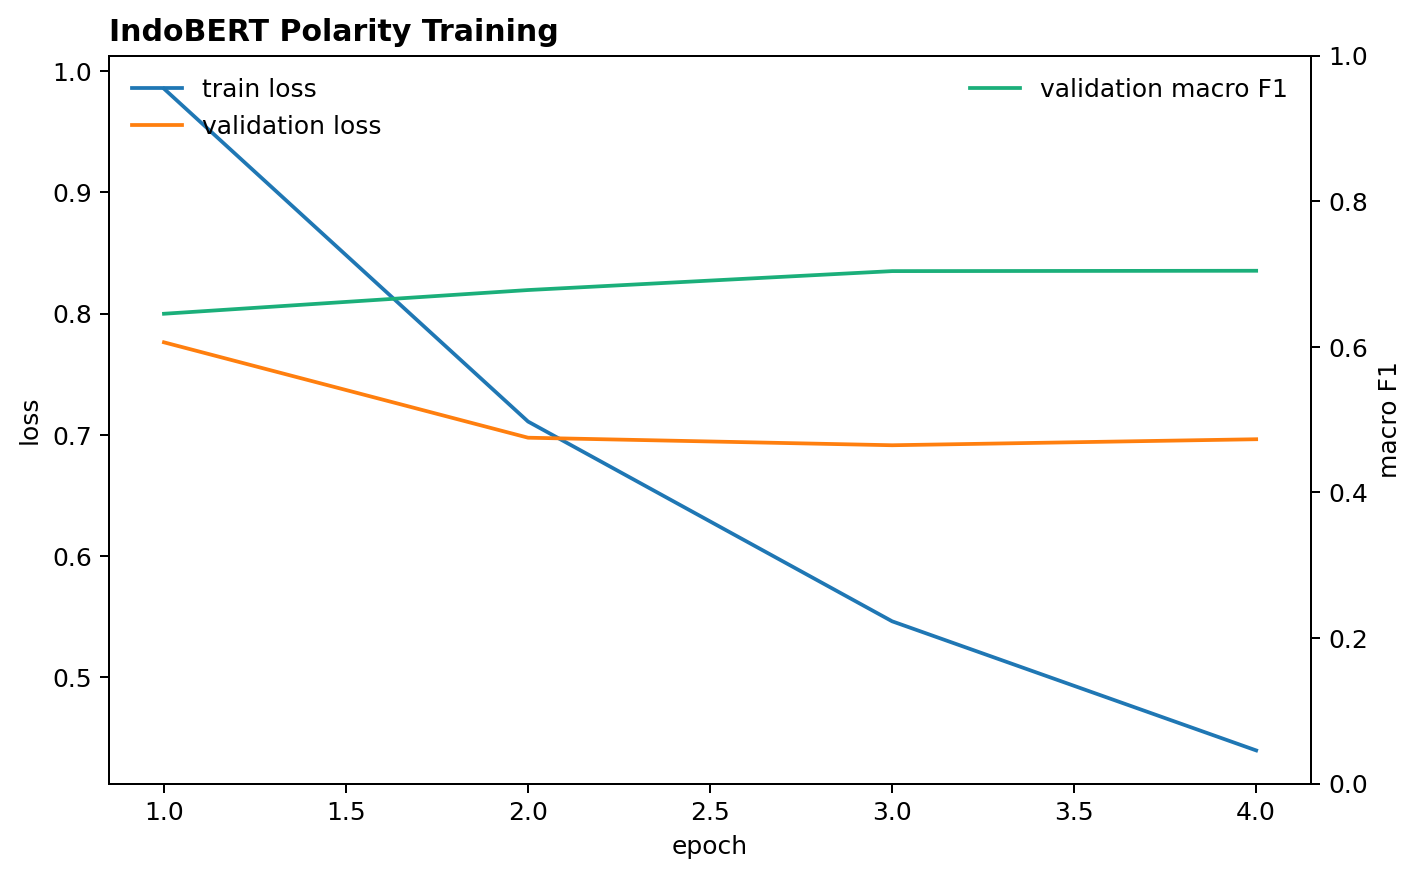

In [10]:
from IPython.display import Image, display
from pathlib import Path

RUN_ID = "20260801-1024_indobert-silver-v1"
run_dir = Path("/content/drive/MyDrive/SIPATURE/runs") / RUN_ID

print("Kurva Aspect Detection")
display(Image(filename=str(
    run_dir / "aspect" / "training-history.png"
)))

print("Kurva Polarity")
display(Image(filename=str(
    run_dir / "polarity" / "training-history.png"
)))

In [11]:
import shutil
from pathlib import Path

RUN_ID = "20260801-1024_indobert-silver-v1"

run_dir = (
    Path("/content/drive/MyDrive/SIPATURE/runs")
    / RUN_ID
)

evidence_dir = (
    Path("/content/drive/MyDrive/SIPATURE")
    / f"{RUN_ID}_evidence"
)

if evidence_dir.exists():
    shutil.rmtree(evidence_dir)

evidence_dir.mkdir(parents=True)

files_to_copy = {
    "summary.json": run_dir / "summary.json",
    "manifest.json": run_dir / "manifest.json",
    "environment.json": run_dir / "environment.json",
    "token-length-coverage.json": run_dir / "token-length-coverage.json",
    "aspect-metrics.json": run_dir / "aspect" / "metrics.json",
    "aspect-trainer-log.json": run_dir / "aspect" / "trainer-log.json",
    "aspect-training-history.png": run_dir / "aspect" / "training-history.png",
    "aspect-model-config.json": run_dir / "aspect" / "model" / "config.json",
    "polarity-metrics.json": run_dir / "polarity" / "metrics.json",
    "polarity-trainer-log.json": run_dir / "polarity" / "trainer-log.json",
    "polarity-training-history.png": run_dir / "polarity" / "training-history.png",
    "polarity-model-config.json": run_dir / "polarity" / "model" / "config.json",
}

for output_name, source in files_to_copy.items():
    assert source.is_file(), f"File tidak ditemukan: {source}"
    shutil.copy2(source, evidence_dir / output_name)

archive_path = shutil.make_archive(
    str(evidence_dir),
    "zip",
    root_dir=evidence_dir,
)

print("Paket bukti A7 berhasil dibuat:")
print(archive_path)
print("\nIsi paket:")

for path in sorted(evidence_dir.iterdir()):
    print(f"- {path.name}: {path.stat().st_size:,} byte")

print(
    "\nUkuran ZIP:",
    f"{Path(archive_path).stat().st_size:,} byte",
)

Paket bukti A7 berhasil dibuat:
/content/drive/MyDrive/SIPATURE/20260801-1024_indobert-silver-v1_evidence.zip

Isi paket:
- aspect-metrics.json: 192 byte
- aspect-model-config.json: 1,547 byte
- aspect-trainer-log.json: 1,923 byte
- aspect-training-history.png: 82,757 byte
- environment.json: 1,115 byte
- manifest.json: 8,533 byte
- polarity-metrics.json: 192 byte
- polarity-model-config.json: 1,044 byte
- polarity-trainer-log.json: 1,926 byte
- polarity-training-history.png: 77,370 byte
- summary.json: 3,377 byte
- token-length-coverage.json: 538 byte

Ukuran ZIP: 145,623 byte


In [7]:
from transformers import AutoConfig

model_config = AutoConfig.from_pretrained(
    MODEL_ID,
    revision=MODEL_REVISION,
)

print("Model type:", model_config.model_type)
print("Vocabulary size:", model_config.vocab_size)
print("Maximum position embeddings:", model_config.max_position_embeddings)
print("Hidden size:", model_config.hidden_size)
print("Jumlah layer:", model_config.num_hidden_layers)
print("Attention heads:", model_config.num_attention_heads)

assert model_config.vocab_size == tokenizer.vocab_size
assert indobert_config["max_length"] <= model_config.max_position_embeddings

print("\nKonfigurasi model dan tokenizer konsisten.")
print(
    f"Max length training {indobert_config['max_length']} "
    f"berada di bawah batas model {model_config.max_position_embeddings}."
)

Model type: bert
Vocabulary size: 50000
Maximum position embeddings: 512
Hidden size: 768
Jumlah layer: 12
Attention heads: 12


AssertionError: 

In [ ]:
from pathlib import Path
from sipature_ml.config import load_config
from sipature_ml.environment import build_environment_snapshot
from sipature_ml.indobert import run_indobert_training, validate_indobert_config

config = load_config('training')
validate_indobert_config(config)
build_environment_snapshot()

In [ ]:
RUN_ID = 'REPLACE_WITH_YYYYMMDD-HHMM_indobert-silver-v1_commit'
summary = run_indobert_training(
    split_dir=Path('data/splits'),
    artifact_dir=Path('/content/drive/MyDrive/SIPATURE'),
    run_id=RUN_ID,
)
summary

In [1]:
!nvidia-smi

Sat Aug  1 09:46:45 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   63C    P8             12W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----